In [18]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import os
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

In [19]:
class RootInterface():
    def __init__(self, path):
        self.load_file(path)
    
    def load_file(self, path):
        self.file = uproot.open(path)
        tree = self.file["event_info"]
        self.evnum = len(tree["eventnumber"].arrays(library="np")["eventnumber"])
        self.ixs = tree["redpix_ix"].arrays(library="np")["redpix_ix"]
        self.iys = tree["redpix_iy"].arrays(library="np")["redpix_iy"]
        self.izs = tree["redpix_iz"].arrays(library="np")["redpix_iz"]
        self.p_shape = self.file[f"pic_run1_ev{0}"].to_numpy()[0].shape

    def get_num_of_events(self):
        return self.evnum

    def get_noisy_image(self, idx):
        return self.file[f"pic_run1_ev{idx}"].to_numpy()[0]

    def get_clean_image(self, idx):
        ix_event = self.ixs[idx]
        iy_event = self.iys[idx]
        iz_event = self.izs[idx]
        image = np.zeros(self.p_shape, dtype=np.uint16)
        image[ix_event, iy_event] = iz_event

        return image

    def plot_noisy_image(self, idx, num_title = -1):
        if num_title == -1:
            num_title = idx
        img = self.get_noisy_image(idx)
        plt.figure(figsize = (8,8))
        plt.title(f"EVENT #{num_title}")
        plt.imshow(img.T, vmin = 99, vmax = 120)
        plt.show()
    
    def plot_clean_image(self, idx, num_title = -1):
        if num_title == -1:
            num_title = idx
        img = self.get_clean_image(idx)
        plt.figure(figsize = (8,8))
        plt.title(f"redpix of EVENT #{num_title}")
        plt.imshow(img.T)
        plt.show()

    def plot_event(self, idx, num_title = -1):
        if num_title == -1:
            num_title = idx
        noisy = self.get_noisy_image(idx)
        clean = self.get_clean_image(idx)

        fig, axs = plt.subplots(1, 2, figsize=(15,15))
        axs[0].imshow(noisy.T, vmin = 99, vmax = 120)
        axs[0].set_title(f"EVENT #{num_title}")
        axs[1].imshow(clean.T)
        axs[1].set_title(f"redpix of EVENT #{num_title}")

class RootManager():
    def __init__(self, dir):
        self.data_dir = dir
        self.files = sorted(os.listdir(self.data_dir))

        self.events_per_file_dict = {}
        self.rootfile_starts_dict = {}
        sum = 0
        for file in self.files:
            path = os.path.join(self.data_dir, file)
            ifc = RootInterface(path)
            tmp = ifc.get_num_of_events()

            self.rootfile_starts_dict[file] = sum
            self.events_per_file_dict[file] = tmp
            sum += tmp
        self.total_events = sum
        self.rootfile_starts_dict["end"] = sum
        #display(self.events_per_file_dict)
        #display(self.rootfile_starts_dict)

        self.load_file(self.files[0])
    
    def load_file(self, file):
        path = os.path.join(self.data_dir, file)
        self.ifc = RootInterface(path)
        self.current_file = file
    
    def update_file_pointer(self, idx):
        if idx >= self.total_events or idx < 0:
            print(f"{idx} is OUT OF BOUNDS!")
            return

        file = ""
        offset = 0
        for key, val in self.rootfile_starts_dict.items():
            #print(key, val)
            if idx >= val:
                file = key
                offset = val
            else:
                break
        #print(f"{idx} sta in {file}")

        if file == "":
            print("SOMETHING WENT WRONG")
            return
        elif file != self.current_file:
            self.load_file(file)
            #print(f"{file} loaded")
        
        #self.ifc.plot_event(idx - offset, idx)
    
    def get_noisy(self, idx):
        self.update_file_pointer(idx)
        offset = self.rootfile_starts_dict[self.current_file]
        return self.ifc.get_noisy_image(idx - offset)
    
    def get_clean(self, idx):
        self.update_file_pointer(idx)
        offset = self.rootfile_starts_dict[self.current_file]
        return self.ifc.get_clean_image(idx - offset)
    
    def get_pair(self, idx):
        return self.get_noisy(idx), self.get_clean(idx)

class ImageDataset(Dataset):
    def __init__(self, dir, transform=None):
        self.rmngr = RootManager(dir)
        self.transform = transform

    def __len__(self):
        return self.rmngr.total_events

    def __getitem__(self, idx):
        img, target = self.rmngr.get_pair(idx)
        if self.transform:
            img = self.transform(img)
            target = self.transform(target)
        
        return img, target


image shape: (2304, 2304)
number of events in dset: 800
Number of batches: 200


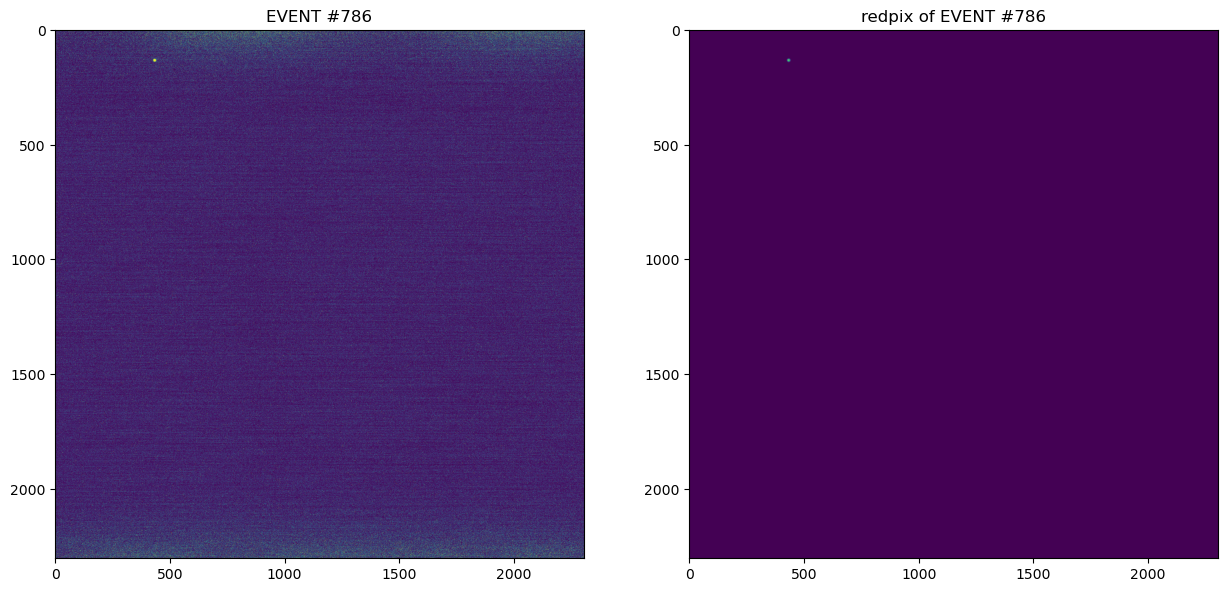

In [20]:
dset = ImageDataset("data")

img_shape = dset.rmngr.ifc.p_shape
print(f"image shape: {img_shape}")
print(f"number of events in dset: {len(dset)}")

roma = RootManager("data")

idxs = [786]

for idx in idxs:
    #img, target = roma.get_pair(idx)
    img, target = dset[idx]
    fig, axs = plt.subplots(1, 2, figsize=(15,15))
    axs[0].imshow(img.T, vmin = 99, vmax = 120)
    axs[0].set_title(f"EVENT #{idx}")
    axs[1].imshow(target.T)
    axs[1].set_title(f"redpix of EVENT #{idx}")

dloader = DataLoader(dset, batch_size=4, shuffle=True)
print('Number of batches:',len(dloader))

Using cpu device
Net(
  (convolutional_relu_stack): Sequential(
    (0): Conv2d(1, 1, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
  )
)
2
<class 'torch.Tensor'>
<class 'torch.Tensor'>


Text(0.5, 1.0, 'EVENT #786')

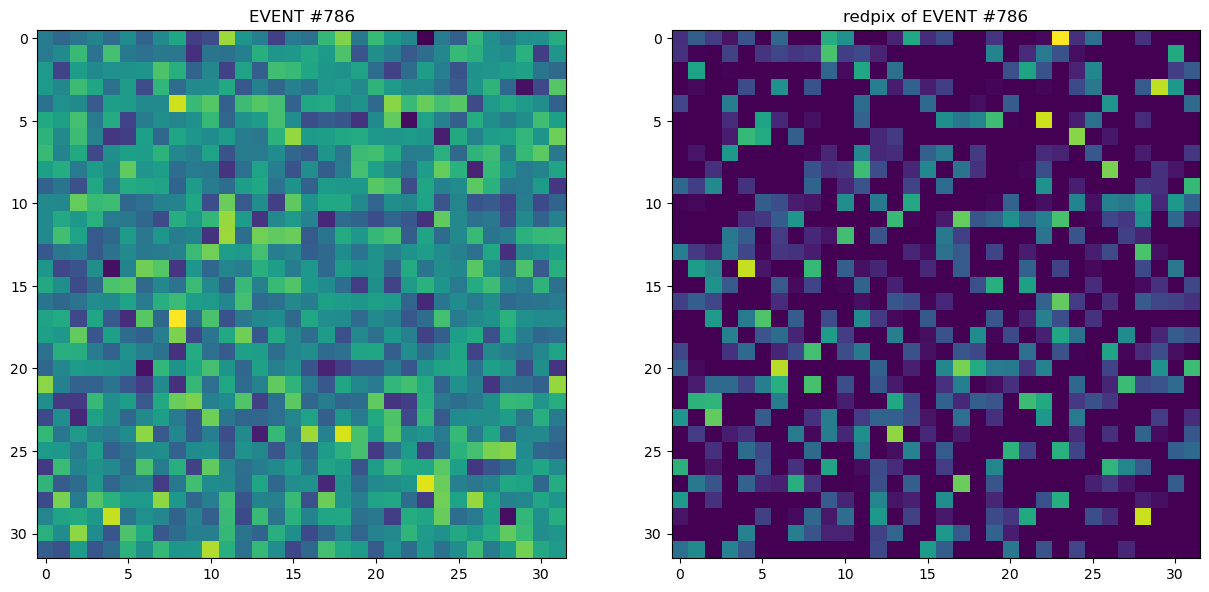

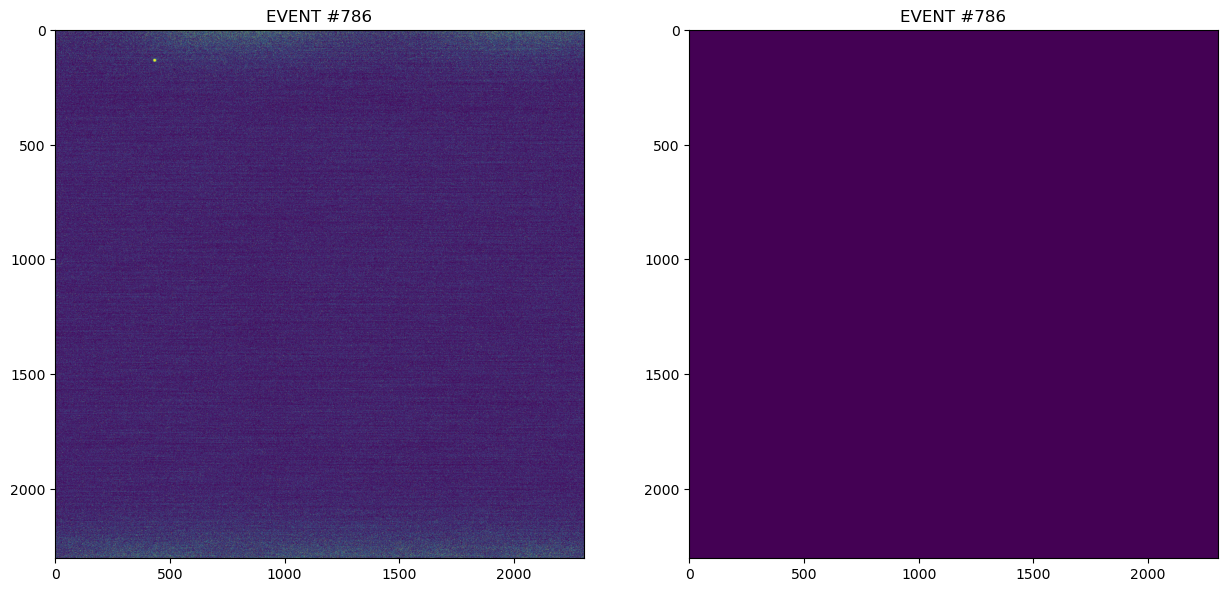

In [23]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutional_relu_stack = nn.Sequential(
            nn.Conv2d(1, 1, 1),
            #nn.Identity(),
            nn.ReLU(),
        )

    def forward(self, x):
        out = self.convolutional_relu_stack(x)
        return out

net = Net()
print(net)
params = list(net.parameters())
print(len(params))
#print(params[0].size()) 

input = torch.from_numpy(np.zeros((10,10), dtype=np.float32))
input = torch.randn(1, 1, 32, 32)
print(type(input))
out = net(input)

fig, axs = plt.subplots(1, 2, figsize=(15,15))
axs[0].imshow(input.squeeze())
axs[0].set_title(f"EVENT #{idx}")
axs[1].imshow(out.detach().squeeze())
axs[1].set_title(f"redpix of EVENT #{idx}")

input = torch.from_numpy(img.astype(np.float32)).unsqueeze(0)
print(type(input))
out = net(input)

fig, axs = plt.subplots(1, 2, figsize=(15,15))
axs[0].imshow(input.squeeze().T, vmin = 99, vmax = 120)
axs[0].set_title(f"EVENT #{idx}")
axs[1].imshow(out.detach().squeeze().T, vmin = 99, vmax = 120)
axs[1].set_title(f"EVENT #{idx}")